In [259]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import barplot

plt.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [145]:
serviceKeyFilePath = "/Volumes/WorkSpace/Notebook/data/OceanMensurationService.json"

In [178]:
serviceInfo = pd.read_json(serviceKeyFilePath)

In [276]:
codeUrl = serviceInfo.endpoint_json[0] + "?key=" + serviceInfo.key[0] + "&id=" + serviceInfo.code[0]
codeRawDf = pd.read_json(codeUrl, encoding='euc-kr')
codeRawDf

,body,header
item,"[{'bld_dat': '2024-05-13', 'lon': '126.7364', ...",NaN
resultMsg,NaN,success
resultCode,NaN,00


In [110]:
codeList = []
for data in codeRawDf.stack().iloc[0]:
    codeList.append(pd.DataFrame.from_dict(data,  orient='index').T)

codeDf = pd.concat(codeList).reset_index()
codeDf

,index,bld_dat,lon,sta_nam_kor,bot_dep,gru_nam,sur_dep,mid_tmp_yn,sta_cde,sta_des,end_dat,sur_tmp_yn,bot_tmp_yn,lat,mid_dep
0,0,2024-05-13,126.7364,완도 대창,None,남해,3,N,fwdo5,None,None,Y,N,34.3825,None
1,0,2024-05-13,127.0837,완도 사동,None,남해,3,N,fwso5,None,None,Y,N,34.3373,None
2,0,2024-05-09,127.0101,완도 감목,None,남해,5,N,fwyo5,None,None,Y,N,34.342,None
3,0,2024-03-11,128.5239,고성 가진,28,동해,5,Y,fggo3,None,None,Y,Y,38.3681,15
4,0,2020-05-28,126.147,태안 파도리,None,서해,1.5,Y,ftpk5,태안군청 신규관측소,None,Y,N,36.7123,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,0,2004-04-09,125.4851,목포(등부표),None,서해,5,N,mp001,전남 신안군 도초면 도초도,2005-04-17,N,N,34.364,None
80,0,2004-02-12,126.187,추자도,None,남해,5,N,jj001,제주시 북제주군 추자도,2006-03-01,N,N,33.5764,None
81,0,2004-02-10,127.3509,고흥,None,남해,5,N,ys002,전남 고흥군 외나로도,2005-01-20,N,N,34.2612,None
82,0,2004-01-02,128.2285,통영,None,남해,5,N,ms001,경남 통영시 욕지면 연화리 연화도,2005-09-23,N,N,34.3961,None


In [171]:
listUrl = serviceInfo.endpoint_json[0] + "?key=" + serviceInfo.key[0] + "&id=" + serviceInfo.list[0]
listRawDf = pd.read_json(listUrl, encoding='euc-kr')
listRawDf

,body,header
item,"[{'sta_nam_kor': '기장', 'wtr_tmp': '11.7', 'obs...",NaN
resultMsg,NaN,success
resultCode,NaN,00


In [179]:
listList = []
for data in listRawDf.stack().iloc[0]:
    listList.append(pd.DataFrame.from_dict(data,  orient='index').T)

listDf = pd.concat(listList).reset_index()
listDf

,index,sta_nam_kor,wtr_tmp,obs_lay,repair_gbn,obs_tim,dox,sta_cde,sal,obs_dat
0,0,기장,11.7,1,1,11:30:00,None,bgj8a,None,2025-02-26
1,0,기장,11.8,2,1,11:30:00,None,bgj8a,None,2025-02-26
2,0,기장,11.8,3,1,11:30:00,None,bgj8a,None,2025-02-26
3,0,강릉,7.2,1,1,11:30:00,None,bgna3,None,2025-02-26
4,0,강릉,7.1,2,1,11:30:00,None,bgna3,None,2025-02-26
...,...,...,...,...,...,...,...,...,...,...
66,0,통영 영운,8.5,1,1,11:30:00,None,ty004,None,2025-02-26
67,0,통영 사량,7.4,1,1,11:30:00,10.3,ty005,None,2025-02-26
68,0,완도 청산,8.1,1,1,11:30:00,10.1,wc001,None,2025-02-26
69,0,완도 금일,7.8,1,1,11:30:00,None,wk094,None,2025-02-26


In [173]:
listDf['date'] = pd.to_datetime(listDf.obs_dat + ' ' +listDf.obs_tim , format='%Y-%m-%d %H:%M:%S')

In [189]:
df = listDf.merge(codeDf, how='left', on='sta_cde')
df

,index_x,sta_nam_kor_x,wtr_tmp,obs_lay,repair_gbn,obs_tim,dox,sta_cde,sal,obs_dat,...,bot_dep,gru_nam,sur_dep,mid_tmp_yn,sta_des,end_dat,sur_tmp_yn,bot_tmp_yn,lat,mid_dep
0,0,기장,11.7,1,1,11:30:00,None,bgj8a,None,2025-02-26,...,15,동해,5,Y,None,None,Y,Y,35.187,10
1,0,기장,11.8,2,1,11:30:00,None,bgj8a,None,2025-02-26,...,15,동해,5,Y,None,None,Y,Y,35.187,10
2,0,기장,11.8,3,1,11:30:00,None,bgj8a,None,2025-02-26,...,15,동해,5,Y,None,None,Y,Y,35.187,10
3,0,강릉,7.2,1,1,11:30:00,None,bgna3,None,2025-02-26,...,30,동해,5,Y,강원도 강릉시 사천면 사천항,None,Y,Y,37.799,20
4,0,강릉,7.1,2,1,11:30:00,None,bgna3,None,2025-02-26,...,30,동해,5,Y,강원도 강릉시 사천면 사천항,None,Y,Y,37.799,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,0,통영 영운,8.5,1,1,11:30:00,None,ty004,None,2025-02-26,...,None,남해,5,N,경남 통영시 산양면 영운리 양식환경연구소 ...,None,Y,N,34.7904,None
67,0,통영 사량,7.4,1,1,11:30:00,10.3,ty005,None,2025-02-26,...,None,남해,5,N,경상남도 통영시 사량면 양지리,None,Y,N,34.8022,None
68,0,완도 청산,8.1,1,1,11:30:00,10.1,wc001,None,2025-02-26,...,None,남해,3,N,전라남도 완도군 청산면 도락리,None,Y,N,34.1698,None
69,0,완도 금일,7.8,1,1,11:30:00,None,wk094,None,2025-02-26,...,None,남해,3.5,N,전남 완도군 금일읍 충동리,None,Y,N,34.3786,None


In [190]:
df = df.astype({'wtr_tmp':'float64'})

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index_x        71 non-null     int64  
 1   sta_nam_kor_x  71 non-null     object 
 2   wtr_tmp        71 non-null     float64
 3   obs_lay        71 non-null     object 
 4   repair_gbn     71 non-null     object 
 5   obs_tim        71 non-null     object 
 6   dox            15 non-null     object 
 7   sta_cde        71 non-null     object 
 8   sal            2 non-null      object 
 9   obs_dat        71 non-null     object 
 10  index_y        71 non-null     int64  
 11  bld_dat        71 non-null     object 
 12  lon            71 non-null     object 
 13  sta_nam_kor_y  71 non-null     object 
 14  bot_dep        21 non-null     object 
 15  gru_nam        71 non-null     object 
 16  sur_dep        71 non-null     object 
 17  mid_tmp_yn     71 non-null     object 
 18  sta_des     

<Axes: xlabel='sta_nam_kor_x'>

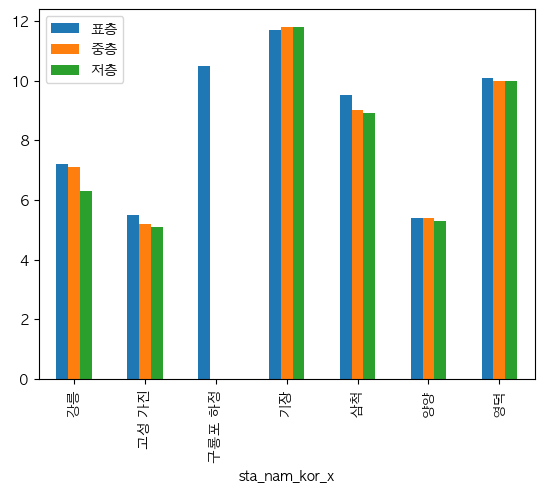

In [263]:
EastDf = df.loc[(df.gru_nam == '동해') & (df.repair_gbn == '1') ][['sta_nam_kor_x', 'obs_lay', 'wtr_tmp']].pivot(index='sta_nam_kor_x', columns='obs_lay', values='wtr_tmp')
EastDf.columns = ['표층', '중층', '저층']
EastDf.plot.bar(stacked=False)

<Axes: xlabel='sta_nam_kor_x'>

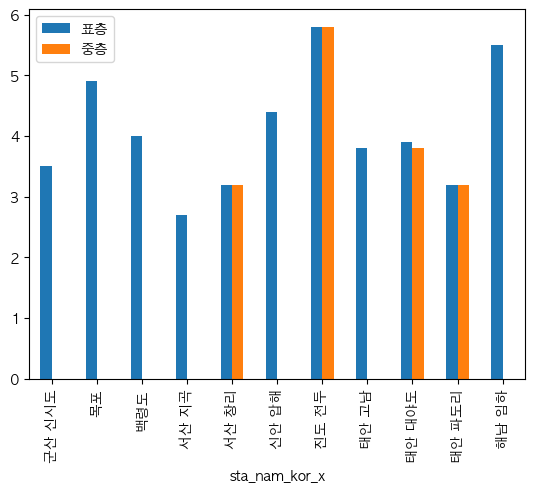

In [256]:
WestDf = df.loc[(df.gru_nam == '서해')  & (df.repair_gbn == '1')][['sta_nam_kor_x', 'obs_lay', 'wtr_tmp']].pivot(index='sta_nam_kor_x', columns='obs_lay', values='wtr_tmp')
WestDf.columns = ['표층', '중층']
WestDf.plot.bar(stacked=False)

<Axes: xlabel='sta_nam_kor_x'>

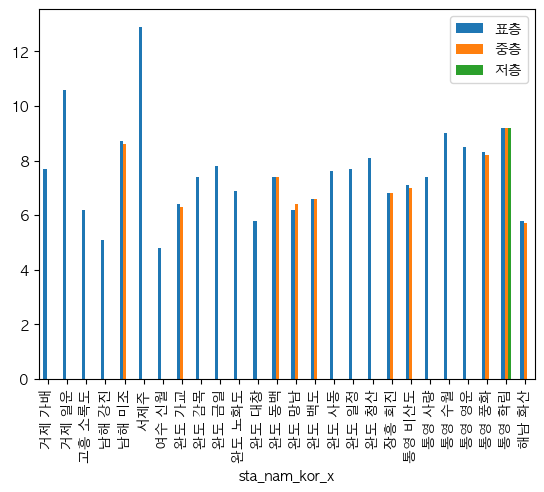

In [255]:
SouthDf = df.loc[(df.gru_nam == '남해')  & (df.repair_gbn == '1')][['sta_nam_kor_x', 'obs_lay', 'wtr_tmp']].pivot(index='sta_nam_kor_x', columns='obs_lay', values='wtr_tmp')
SouthDf.columns = ['표층', '중층', '저층']
SouthDf.plot.bar(stacked=False)